In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans,AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
iris=datasets.load_iris()
x=iris.data
y=iris.target
feature_names=iris.feature_names
df=pd.DataFrame(x,columns=feature_names)
df['target']=y
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
pd.DataFrame(x_scaled,columns=feature_names).head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


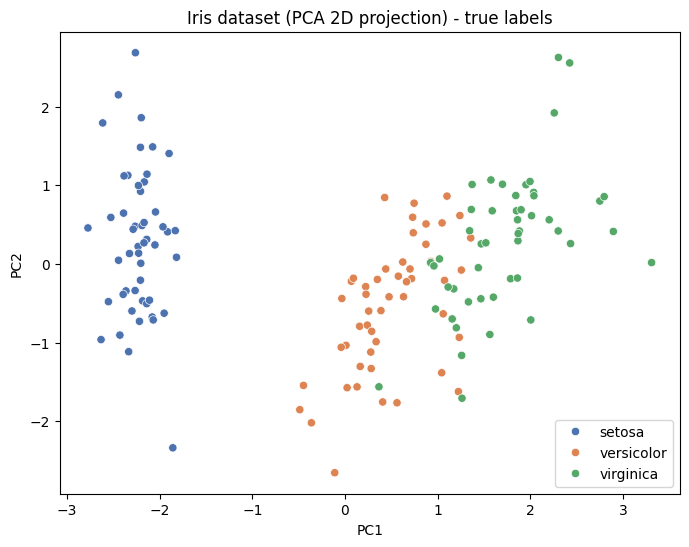

In [ ]:
pca=PCA(n_components=2,random_state=42)
x_pca=pca.fit_transform(x_scaled)
plt.figure(figsize=(8,6))
sns.scatterplot(x=x_pca[:,0], y=x_pca[:,1], hue=iris.target_names[y], palette='deep')
plt.title('Iris dataset (PCA 2D projection) - true labels')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.show()

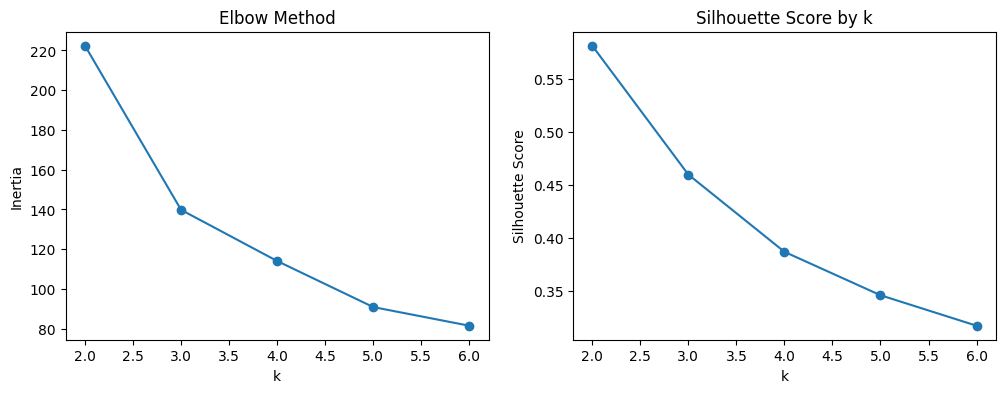

In [ ]:
inertias = []
sil_scores = []
K = range(2,7)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(x_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(x_scaled, labels))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(K, inertias, '-o')
plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Elbow Method')

plt.subplot(1,2,2)
plt.plot(K, sil_scores, '-o')
plt.xlabel('k'); plt.ylabel('Silhouette Score'); plt.title('Silhouette Score by k')
plt.show()


In [ ]:
k=3
km=KMeans(n_clusters=k,random_state=42,n_init=10)
labels=km.fit_predict(x_scaled)
print('Silhouette score (k=3):', round(silhouette_score(x_scaled, labels),3))

Silhouette score (k=3): 0.46


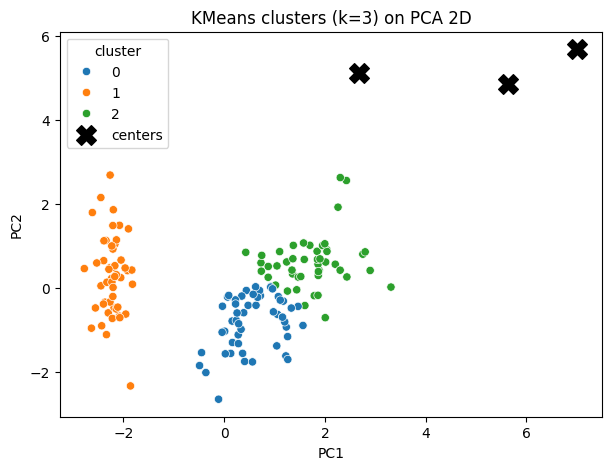

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=x_pca[:,0], y=x_pca[:,1], hue=labels, palette='tab10', legend='full')
centers = pca.transform(scaler.inverse_transform(km.cluster_centers_))  # project cluster centers to PCA space
plt.scatter(centers[:,0], centers[:,1], c='black', s=200, marker='X', label='centers')
plt.title(f'KMeans clusters (k={k}) on PCA 2D'); plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(title='cluster')
plt.show()

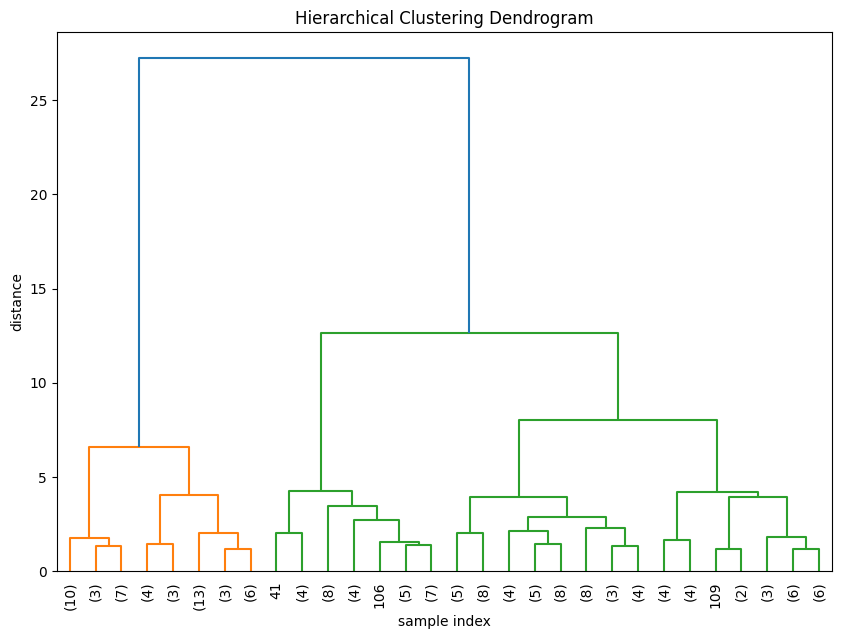

In [ ]:
linked=linkage(x_scaled,method='ward')
plt.figure(figsize=(10,7))
dendrogram(linked,truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('sample index')
plt.ylabel('distance')
plt.show()

In [ ]:
agg=AgglomerativeClustering(n_clusters=3, linkage='ward')
labels=agg.fit_predict(x_scaled)
print('Silhouette score (agglomerative, n=3):', round(silhouette_score(x_scaled, labels),3))

Silhouette score (agglomerative, n=3): 0.447


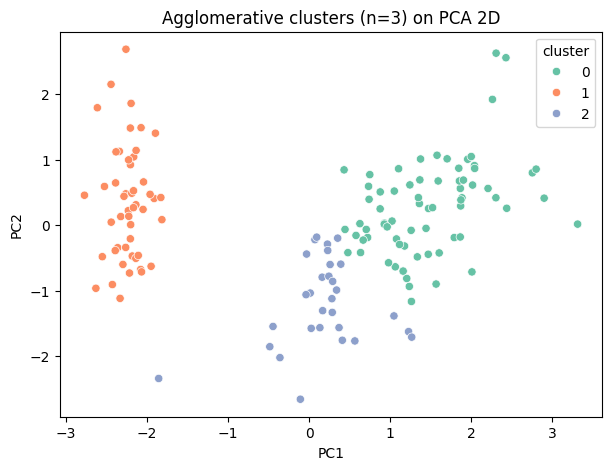

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=x_pca[:,0], y=x_pca[:,1], hue=labels, palette='Set2', legend='full')
plt.title('Agglomerative clusters (n=3) on PCA 2D'); plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(title='cluster')
plt.show()